Investigação
---

*600 promoções realizadas nos últimos anos*

> Mulheres demoram mais para ser promovidas? Compare o meses_no_cargo_anterior entre homens e mulheres no histórico de promoções.

> No histórico de promoções, compare meses_no_cargo_anterior por sexo — mulheres esperam ~40% mais?

> Funcionários com satisfação ≤ 2 e sem promoção são os mais propensos a sairpas









`Importação das bibliotecas`

In [59]:
# Bibliotecas principais
import pandas as pd
import numpy as np

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

`Carregar os datasets`

In [60]:
df_historico_promocoes = pd.read_csv("/projeto_07_historico_promocoes (1).csv")

In [88]:
df_historico_promocoes.head(600)

df_historico_promocoes["Ano"] = df_historico_promocoes["meses_no_cargo_anterior"]/12
df_historico_promocoes["Ano"] = df_historico_promocoes["Ano"].round()
print(df_historico_promocoes)

    funcionario_id sexo departamento cargo_anterior   cargo_novo  \
0        FUN-00705    F      Produto         Sênior  Coordenador   
1        FUN-00334    M      Produto         Júnior        Pleno   
2        FUN-00380    M    Marketing          Pleno       Sênior   
3        FUN-00953    F           RH         Júnior        Pleno   
4        FUN-00463    M   Financeiro         Sênior  Coordenador   
..             ...  ...          ...            ...          ...   
595      FUN-01100    M   Engenharia         Júnior        Pleno   
596      FUN-00708    F       Vendas         Júnior        Pleno   
597      FUN-00966    F           RH         Júnior        Pleno   
598      FUN-00408    F       Vendas         Júnior        Pleno   
599      FUN-00298    F       Vendas         Júnior        Pleno   

    data_promocao  meses_no_cargo_anterior  salario_anterior  salario_novo  \
0      2021-08-02                       36          10535.55      12261.65   
1      2021-01-13          

`Limpeza de dados`

In [74]:
df_historico_promocoes["data_promocao"] = pd.to_datetime(df_historico_promocoes["data_promocao"], errors="coerce")

df_historico_promocoes["sexo"] = df_historico_promocoes["sexo"].astype("category")
df_historico_promocoes["departamento"] = df_historico_promocoes["departamento"].astype("category")

`Detectar outliers`

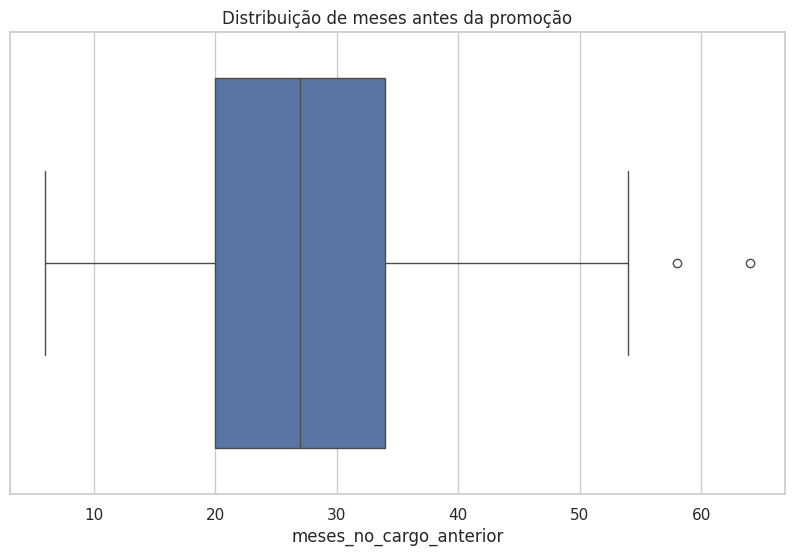

In [90]:
sns.boxplot(x=df_historico_promocoes["meses_no_cargo_anterior"])
plt.title("Distribuição de meses antes da promoção")
plt.show()
df_historico_promocoes = df_historico_promocoes[df_historico_promocoes["meses_no_cargo_anterior"] < 120]

`Hipótese de gênero`

In [91]:
# Mulheres esperam mais tempo para serem promovidas?

tempo_promocao = df_historico_promocoes.groupby("sexo")["Ano"].agg(
    media="mean",
    mediana="median",
    desvio="std",
    quantidade="count"
)
#inserir código para os gráficos
tempo_promocao

/tmp/ipykernel_735/2922446432.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tempo_promocao = df_historico_promocoes.groupby("sexo")["Ano"].agg(


,media,mediana,desvio,quantidade
sexo,,,,
F,2.645390,3.0,0.869693,282
M,1.902516,2.0,0.719222,318


`Boxplot comparativo`

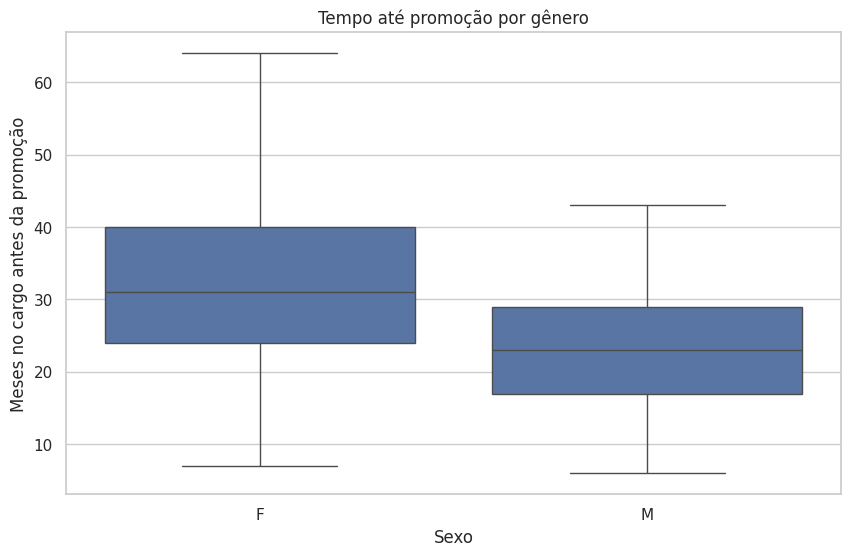

In [93]:
# Esse gráfico revela rapidamente desigualdade estrutural.

sns.boxplot(
    data=df_historico_promocoes,
    x="sexo",
    y="meses_no_cargo_anterior"
)

plt.title("Tempo até promoção por gênero")
plt.xlabel("Sexo")
plt.ylabel("Meses no cargo antes da promoção")

plt.show()

`Violinplot`

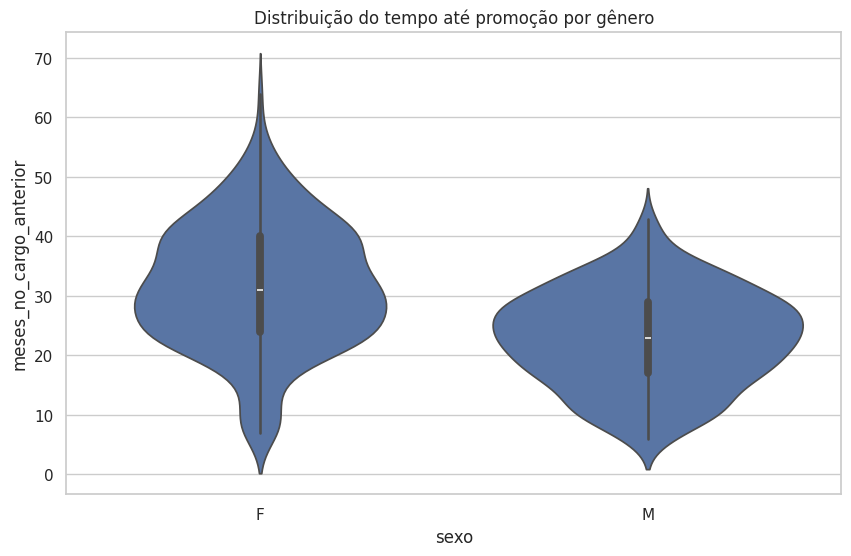

In [79]:
sns.violinplot(
    data=df_historico_promocoes,
    x="sexo",
    y="meses_no_cargo_anterior"
)

plt.title("Distribuição do tempo até promoção por gênero")

plt.show()

`Promoções por gênero`

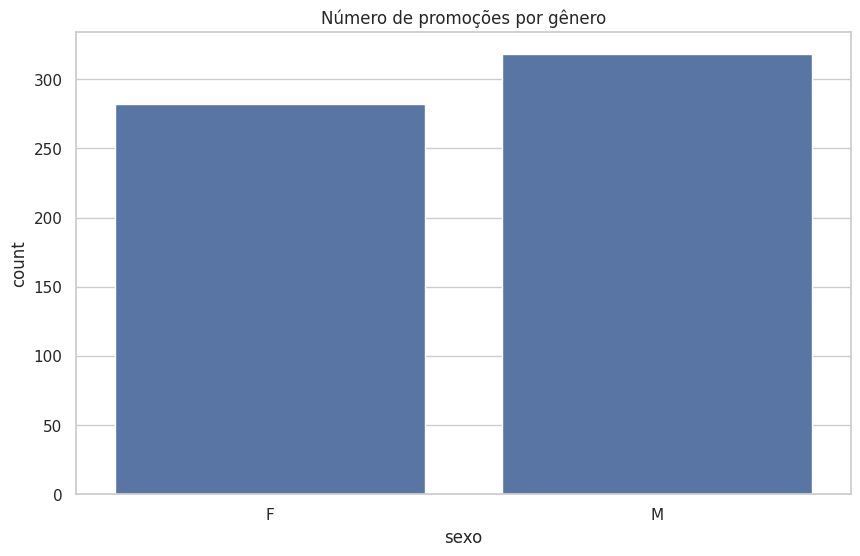

In [83]:
sns.countplot(
    data=df_historico_promocoes,
    x="sexo"
)

plt.title("Número de promoções por gênero")
plt.show()

`Análise por departamento`

/tmp/ipykernel_735/2482224296.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tempo_departamento = df_historico_promocoes.groupby(


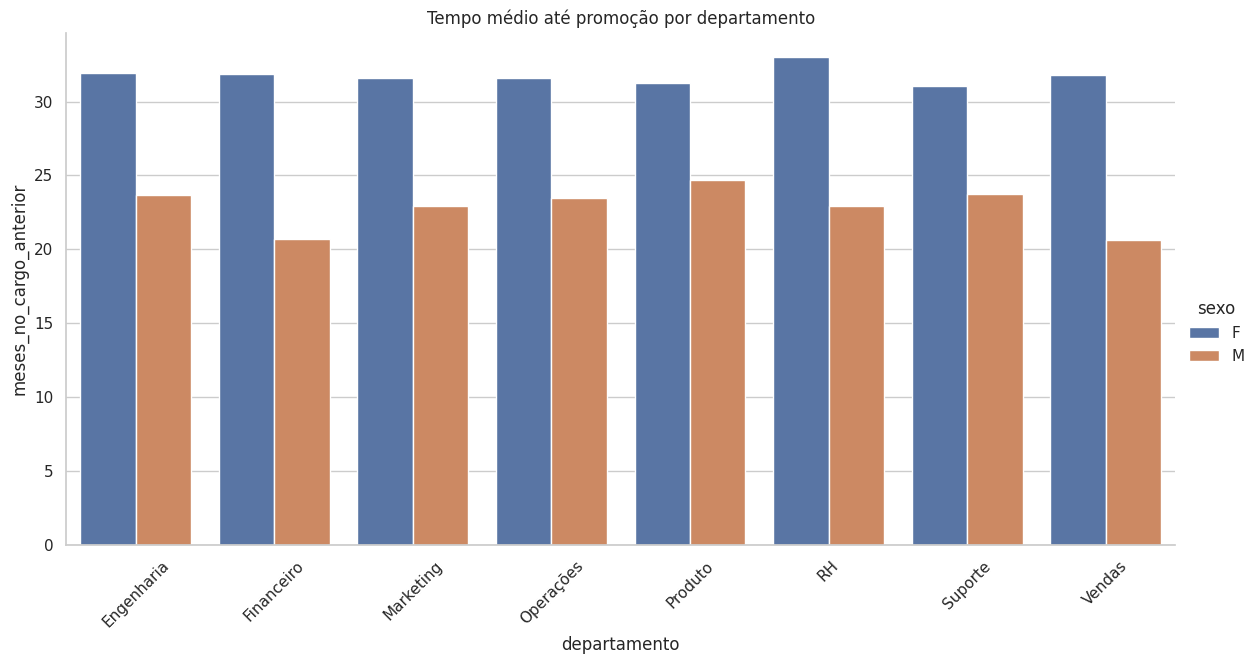

In [94]:
# Aqui começam a aparecer padrões organizacionais (possível gestor tóxico)
tempo_departamento = df_historico_promocoes.groupby(
    ["departamento","sexo"]
)["meses_no_cargo_anterior"].mean().reset_index()

tempo_departamento.head()

sns.catplot(
    data=tempo_departamento,
    x="departamento",
    y="meses_no_cargo_anterior",
    hue="sexo",
    kind="bar",
    height=6,
    aspect=2
)

plt.xticks(rotation=45)

plt.title("Tempo médio até promoção por departamento")

plt.show()

In [ ]:
# Tempo médio de promoção por cargo com a variação por sexo,

